In [1]:
import mysql.connector
from dotenv import load_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
load_dotenv()

db = mysql.connector.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)
mycursor = db.cursor()
print(db)

In [3]:
products_df = pd.read_csv('./data/products - products.csv')
order_line_items_df = pd.read_csv('./data/order_line_items.csv')
order_transactions_df = pd.read_csv('./data/order_transactions.csv')
customers_df = pd.read_csv('./data/customers.csv')
marketing_df = pd.read_csv('./data/order_marketing_details - order_marketing_details.csv')

### The return reasons in order_line_items is qualitative data that I want to convert into qualitative data to use in the analysis, i will do this by using an sql query to create a new table which only contains order_transaction_id, product_id, quantity and the returned_reason.

In [4]:
query = """SELECT
      order_transaction_id,
      product_id,
      quantity,
      CASE
      WHEN return_reason LIKE "%long%"
        OR return_reason LIKE "%big%"
        OR return_reason LIKE "%fit%"
        OR return_reason LIKE "%tight%"
        THEN "size"
      WHEN return_reason LIKE "%quality%"
        OR return_reason LIKE "%fabric%"
        THEN "quality"
      WHEN return_reason LIKE "%order%"
        THEN "order error"
      WHEN return_reason LIKE '%shipping%'
        THEN "shipping or timing"
      WHEN return_reason IS NULL AND order_transaction_id LIKE "RET%"
        THEN "other"
      ELSE NULL
      END as returned_reason
    FROM order_line_items
    WHERE quantity < 0 """
returned_reasons = pd.read_sql(query,db)

In [5]:
returned_reasons.head()

,order_transaction_id,product_id,quantity,returned_reason
0,RET#3304566,32645808783438,-1,shipping or timing
1,RET#3304566,28619227922510,-1,shipping or timing
2,RET#3304566,39614897619022,-1,shipping or timing
3,RET#3304566,39926153052238,-1,shipping or timing
4,RET#3304967,32841360703566,-1,size


# 1.How are specific products performing?

In [6]:
query = """SELECT
SUBSTRING_INDEX(product_name, "-", 1) AS product_name,  
product_colour,
product_size,
SUM(quantity) as sum_quantity,
CASE
 WHEN SUM(quantity) > 100 THEN "High"
 WHEN SUM(quantity) > 20 THEN "Medium"
 WHEN SUM(quantity) > 5 THEN "Low"
 ELSE "Very Low"
END AS demand
FROM  products as p
LEFT JOIN order_line_items as oli
ON oli.product_id = p.product_id
WHERE quantity >= 0
GROUP BY product_name, product_colour, product_size
ORDER BY sum_quantity DESC, product_name, product_colour,product_size """
product_demand = pd.read_sql(query,db)

In [7]:
product_demand.head(10)

,product_name,product_colour,product_size,sum_quantity,demand
0,Long Sleeved Shirt,Sand,Large,477.0,High
1,Long Sleeved Shirt,Sand,Medium,470.0,High
2,Long Sleeved Shirt,Sand,XL,270.0,High
3,Long Sleeved Shirt,Ember,Large,264.0,High
4,Long Sleeved Shirt,Dusk,Large,237.0,High
5,Long Sleeved Shirt,Ember,Medium,222.0,High
6,Long Sleeved Shirt,Sand,1X,184.0,High
7,Long Sleeved Shirt,Dusk,Medium,183.0,High
8,Long Sleeved Shirt,Ember,XL,136.0,High
9,Long Sleeved Shirt,Dusk,XL,131.0,High


### There are 530 products which have sold 5 or less products in the past month, I would suggest to the founder that they should stop producing these products as they have very low demand and take up a lot of storage space for little return.
### They should also be aware of which products are performing the best so that they can ensure enough product is produced to keep up with demand.

In [8]:
very_low_demand = product_demand[product_demand['demand'] == "Very Low"]
print(very_low_demand)

            product_name product_colour product_size  sum_quantity    demand
303      Buttoned Shirt            Sand           1X           5.0  Very Low
304      Buttoned Shirt            Sand           2X           5.0  Very Low
305      Buttoned Shirt            Sand           XL           5.0  Very Low
306                Coat            Moss        Small           5.0  Very Low
307                Coat            Sand           1X           5.0  Very Low
..                   ...            ...          ...           ...       ...
828  Universal Trousers       Jet Black           3X           1.0  Very Low
829  Universal Trousers       Jet Black           XS           1.0  Very Low
830  Universal Trousers           Slate        Large           1.0  Very Low
831  Universal Trousers           Slate       Medium           1.0  Very Low
832  Universal Trousers           Slate           XL           1.0  Very Low

[530 rows x 5 columns]


# 2. How do our customers find us?

In [9]:
query = """ WITH tot_revnue AS (
  SELECT
order_transaction_id, revenue
FROM order_line_items
WHERE revenue>0
)
SELECT
   ROUND(SUM(r.revenue),2) AS total_revenue,
   CASE 
     WHEN LOWER(omd.marketing_source) LIKE '%facebook%' THEN 'Facebook'
     WHEN LOWER(omd.marketing_source) LIKE '%instagram%' THEN 'Instagram'
     ELSE omd.marketing_source
   END AS marketing_source,
   COUNT(*) AS count
FROM tot_revnue as r
LEFT JOIN order_transactions as ot
ON r.order_transaction_id = ot.order_transaction_id
LEFT JOIN  order_marketing_details as omd
ON ot.order_transaction_id = omd.transaction_id  
WHERE marketing_source IS NOT NULL
GROUP BY  
   CASE 
     WHEN LOWER(omd.marketing_source) LIKE '%facebook%' THEN 'Facebook'
     WHEN LOWER(omd.marketing_source) LIKE '%instagram%' THEN 'Instagram'
     ELSE omd.marketing_source
   END
ORDER BY total_revenue DESC """
revenue_by_source = pd.read_sql(query,db)

In [10]:
revenue_by_source

,total_revenue,marketing_source,count
0,167013.45,google,2445
1,132500.21,Facebook,1967
2,112157.63,(direct),1676
3,76272.00,Email,1194
4,17161.31,partner,242
5,12087.58,Instagram,187
6,7990.26,bing,117
7,2729.60,pinterest,35
8,2214.59,duckduckgo,35
9,2198.11,retailme.com,33


### The above query shows that the majority of our customers are from 4 main sources - google, facebook campaigns, direct searches and the welcome flow email.

In [11]:
query = """ WITH tot_revnue AS (
  SELECT
order_transaction_id, revenue
FROM order_line_items
WHERE revenue>0
)
SELECT
   ROUND(SUM(r.revenue),2) AS total_revenue,
   omd.marketing_source,
   omd.marketing_medium,  
   omd.marketing_campaign,
   COUNT(*) AS count
FROM tot_revnue as r
LEFT JOIN order_transactions as ot
ON r.order_transaction_id = ot.order_transaction_id
LEFT JOIN  order_marketing_details as omd
ON ot.order_transaction_id = omd.transaction_id  
WHERE marketing_source IS NOT NULL
GROUP BY  omd.marketing_campaign, omd. marketing_source, omd.marketing_medium
ORDER BY total_revenue DESC """
revenue_by_source = pd.read_sql(query,db)

In [12]:
revenue_by_source.head()

,total_revenue,marketing_source,marketing_medium,marketing_campaign,count
0,116748.91,google,organic,(organic),1741
1,112157.63,(direct),(none),,1676
2,76272.00,Email,email,welcome flow email,1194
3,29910.55,facebook,cpc,fb_ts_prospecting_dv24_campaign,470
4,26101.49,facebook,cpc,fb_prospecting_urbanloom_all_2024,390


### There is no data on the cost of the campaigns so it is difficult the compare how cost effective the campaigns ran but they make up a big portion of the revenue. If this data is added I could compare the campaigns to see what works well to improve future campaigns.

# 3. Sales and Returns of products over time 

In [13]:
query = """
SELECT
  prduct_name,
  order_transaction_type,
  GROUP_CONCAT(DISTINCT returned_reason SEPARATOR ', ') AS reasons_for_return,
  COALESCE(ROUND(AVG(delivery_time), 1), 0) AS avg_delivery_time,
  COALESCE(MAX(delivery_time), 0) AS max_delivery_time,
  COALESCE(SUM(sold_Jan_24), 0) AS sold_Jan_24,
  COALESCE(SUM(returned_Jan_24), 0) AS returned_Jan_24,
  COALESCE(SUM(sold_Feb_24), 0) AS sold_Feb_24,
  COALESCE(SUM(returned_Feb_24), 0) AS returned_Feb_24,
  COALESCE(SUM(sold_Mar_24), 0) AS sold_Mar_24,
  COALESCE(SUM(returned_Mar_24), 0) AS returned_Mar_24,
  COALESCE(SUM(sold_Apr_24), 0) AS sold_Apr_24,
  COALESCE(SUM(returned_Apr_24), 0) AS returned_Apr_24,
  COALESCE(SUM(sold_May_24), 0) AS sold_May_24,
  COALESCE(SUM(returned_May_24), 0) AS returned_May_24,
  COALESCE(SUM(sold_Jun_24), 0) AS sold_Jun_24,
  COALESCE(SUM(returned_Jun_24), 0) AS returned_Jun_24,
  COALESCE(SUM(sold_Jul_24), 0) AS sold_Jul_24,
  COALESCE(SUM(returned_Jul_24), 0) AS returned_Jul_24
FROM
(
  WITH updated_data AS
  (
    WITH order_line_updated AS
    (
      SELECT
        order_transaction_id,
        product_id,
        quantity,
        CASE
          WHEN return_reason LIKE '%long%'
            OR return_reason LIKE '%big%'
            OR return_reason LIKE '%fit%'
            OR return_reason LIKE '%tight%'
            THEN 'size'
          WHEN return_reason LIKE '%quality%'
            OR return_reason LIKE '%fabric%'
            THEN 'quality'
          WHEN return_reason LIKE '%order%'
            THEN 'order error'
          WHEN return_reason LIKE '%shipping%'
            THEN 'shipping or timing'
          WHEN return_reason IS NULL AND order_transaction_id LIKE 'RET%'
            THEN 'other'
          ELSE NULL
        END AS returned_reason
      FROM order_line_items
    ),
    delivery_received AS
    (
      SELECT *, COALESCE(delivered_date, pick_up_date, warehouse_received_date) AS received_date
      FROM order_transactions
    )
    SELECT
      SUBSTRING_INDEX(product_name, '-', 1) AS prduct_name,
      order_transaction_type,
      returned_reason,
      CASE WHEN quantity > 0 THEN quantity ELSE NULL END AS sale_quantity,
      ABS(CASE WHEN quantity < 0 THEN quantity ELSE NULL END) AS return_quantity,
      DATE_FORMAT(order_transaction_date, '%Y-%m-01') AS order_month,
      DATEDIFF(received_date, order_transaction_date) AS delivery_time
    FROM order_line_updated olu
    LEFT JOIN products AS p
      ON olu.product_id = p.product_id
    LEFT JOIN delivery_received dr
      ON olu.order_transaction_id = dr.order_transaction_id
  )
  SELECT
    prduct_name,
    order_transaction_type,
    returned_reason,
    delivery_time,
    SUM(CASE WHEN order_month = '2024-01-01' THEN sale_quantity END)   AS sold_Jan_24,
    SUM(CASE WHEN order_month = '2024-01-01' THEN return_quantity END) AS returned_Jan_24,
    SUM(CASE WHEN order_month = '2024-02-01' THEN sale_quantity END)   AS sold_Feb_24,
    SUM(CASE WHEN order_month = '2024-02-01' THEN return_quantity END) AS returned_Feb_24,
    SUM(CASE WHEN order_month = '2024-03-01' THEN sale_quantity END)   AS sold_Mar_24,
    SUM(CASE WHEN order_month = '2024-03-01' THEN return_quantity END) AS returned_Mar_24,
    SUM(CASE WHEN order_month = '2024-04-01' THEN sale_quantity END)   AS sold_Apr_24,
    SUM(CASE WHEN order_month = '2024-04-01' THEN return_quantity END) AS returned_Apr_24,
    SUM(CASE WHEN order_month = '2024-05-01' THEN sale_quantity END)   AS sold_May_24,
    SUM(CASE WHEN order_month = '2024-05-01' THEN return_quantity END) AS returned_May_24,
    SUM(CASE WHEN order_month = '2024-06-01' THEN sale_quantity END)   AS sold_Jun_24,
    SUM(CASE WHEN order_month = '2024-06-01' THEN return_quantity END) AS returned_Jun_24,
    SUM(CASE WHEN order_month = '2024-07-01' THEN sale_quantity END)   AS sold_Jul_24,
    SUM(CASE WHEN order_month = '2024-07-01' THEN return_quantity END) AS returned_Jul_24
  FROM updated_data
  GROUP BY prduct_name, order_transaction_type, returned_reason, delivery_time
) AS pivoted
GROUP BY prduct_name, order_transaction_type
ORDER BY prduct_name DESC, order_transaction_type DESC;
"""
sales_returns_time = pd.read_sql(query, db)

## Below is a pivot table showing the sales and returns by product type over time

In [14]:
sales_returns_time.head(10)

,prduct_name,order_transaction_type,reasons_for_return,avg_delivery_time,max_delivery_time,sold_Jan_24,returned_Jan_24,sold_Feb_24,returned_Feb_24,sold_Mar_24,returned_Mar_24,sold_Apr_24,returned_Apr_24,sold_May_24,returned_May_24,sold_Jun_24,returned_Jun_24,sold_Jul_24,returned_Jul_24
0,Universal Trousers,Sale,None,5.0,9,8.0,0.0,4.0,0.0,8.0,0.0,11.0,0.0,7.0,0.0,11.0,0.0,0.0,0.0
1,Universal Trousers,Return,"quality, size",0.0,0,0.0,4.0,0.0,1.0,0.0,2.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0
2,ThreadJean Wide Leg,Sale,None,4.5,8,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0
3,ThreadJean Wide Leg,Return,size,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,ThreadJean Straight,Sale,None,4.4,8,1.0,0.0,2.0,0.0,2.0,0.0,2.0,0.0,3.0,0.0,3.0,0.0,0.0,0.0
5,ThreadJean Straight,Return,size,0.0,0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,ThreadJean Skinny,Sale,None,4.0,7,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
7,ThreadJean Skinny,Return,quality,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8,ThreadJean Short Sleeve Top,Sale,None,3.5,5,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,ThreadJean Short Sleeve Top,Return,order error,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


## Ploting a graph of product category sales and returns over time

In [15]:
sales = ((order_line_items_df.merge(products_df, on='product_id')).merge(order_transactions_df, on='order_transaction_id'))

In [16]:
sales['order_transaction_date'] = pd.to_datetime(sales['order_transaction_date'])
sales['transaction_type'] = sales['quantity'].apply(lambda x: 'Sale' if x > 0 else 'Return')

In [17]:

grouped = (
    sales.groupby([pd.Grouper(key='order_transaction_date', freq="ME"), 
                  'product_category', 'transaction_type'])['quantity']
    .sum()
    .reset_index()
)

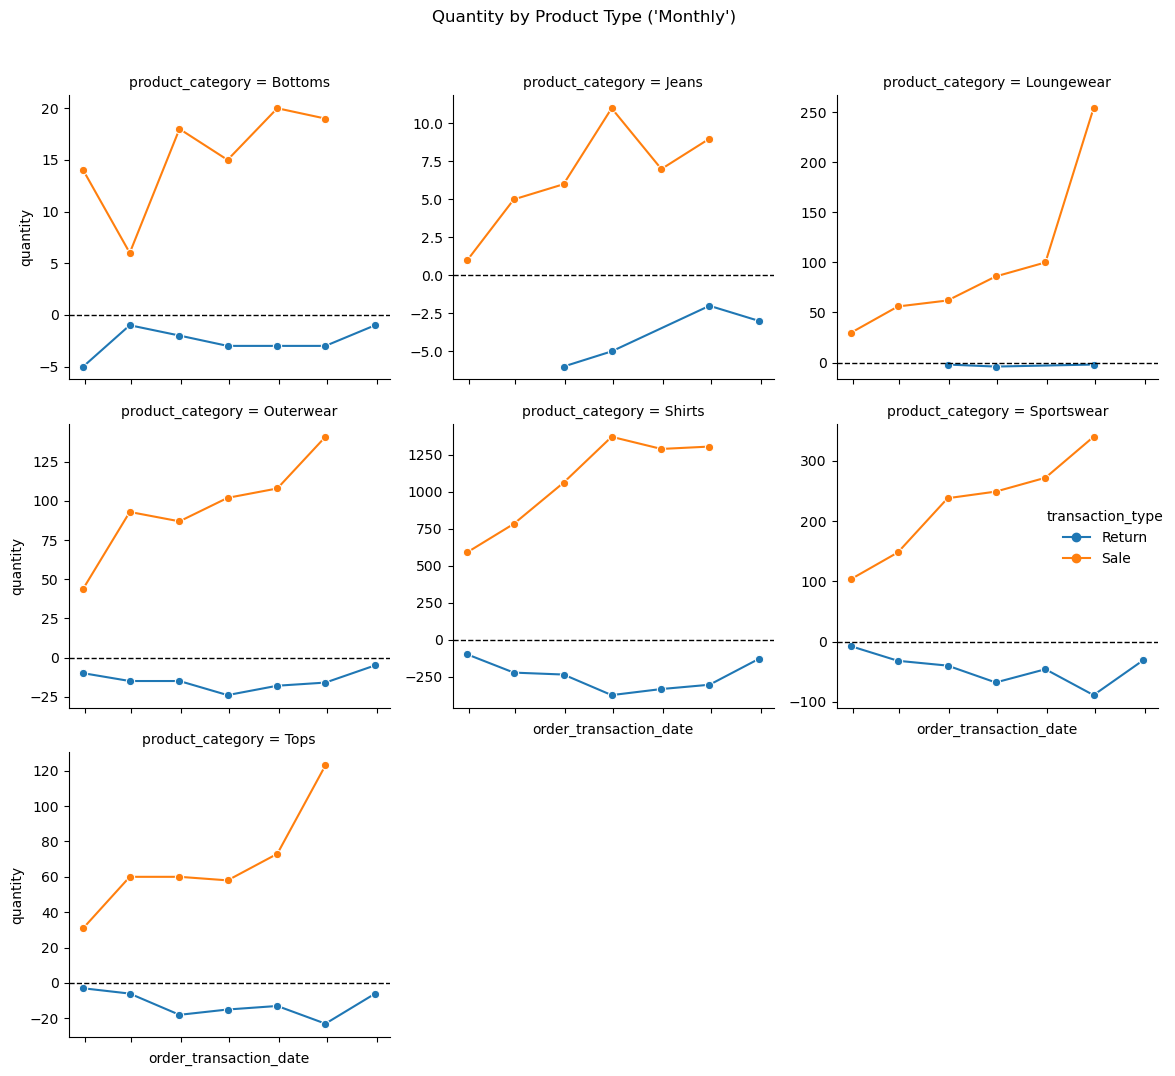

In [18]:
g = sns.relplot(
    data=grouped,
    x='order_transaction_date',
    y='quantity',
    hue='transaction_type',
    col='product_category',
    col_wrap=3,
    kind='line',
    marker='o',
    height=3.5,
    facet_kws={'sharey': False}
)
g.map(plt.axhline, y=0, color='black', linewidth=1, linestyle='--')
g.set_xticklabels(rotation=45)
g.fig.suptitle(f"Quantity by Product Type ('Monthly')", y=1.02)
plt.tight_layout()
plt.show()

### The graphs show that jeans have the highest percentage of returns but it's not too relevant because quantity sold per month is very low. Focus should be spent on categories with higher sales like shirts which also have a high return rate but a much larger quantity. We could look into return reasons and see that the majority of products returned are due to size. We could possible remedy this problem by improving the product size charts to be clearer and more consistent with what consumers are used to, we could have information on how the clothing will fit on the body (e.g. how stretchy/rigid it is)

In [19]:
query = """SELECT SUM(quantity) as sum_quantity, product_id, returned_reason
FROM reason_for_return
WHERE quantity < 0
GROUP BY product_id, returned_reason
ORDER BY sum_quantity ASC, returned_reason """
return_reason = pd.read_sql(query,db)
return_reason

,sum_quantity,product_id,returned_reason
0,-114.0,39399871676494,size
1,-93.0,39399871709262,size
2,-63.0,39399871742030,size
3,-61.0,39399871447118,size
4,-45.0,39399871414350,size
...,...,...,...
641,-1.0,32841360408654,style
642,-1.0,39399871840334,style
643,-1.0,39926154428494,style
644,-1.0,39399871807566,style
